# 03 — Self-Supervised Pre-Training (SimCLR)

Train the ST-GCN encoder on **unlabeled ShuttleSet** skeletons using
contrastive learning (NT-Xent loss) with an auxiliary shot-type classification head.

**Player ordering:** Skeletons are loaded with the hitting player at nodes 0–16
and the opponent at nodes 17–33 (enforced by `dataset.py` using `player_location_y`
from ShuttleSet JSON records — active once per-shot skeleton files are extracted).

**Steps:**
1. Load ShuttleSet unlabeled skeletons (or placeholder zeros until notebook 02 runs)
2. Configure augmentation pipeline (jitter, crop, rotate, mask)
3. Train SimCLR with NT-Xent loss + auxiliary shot-type head
4. Linear probe evaluation on FineBadminton
5. Save encoder weights to `models/ssl_pretrained_{FEATURE_LAYER}.pt`

In [1]:
import sys
sys.path.insert(0, '..')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from src.config import *
from src.data.graph_builder import GraphBuilder
from src.data.dataset import ShuttleSetDataset
from src.models.stgcn_model import STGCN
from src.models.simclr_loss import (
    NTXentLoss, ProjectionHead, SkeletonAugmentor, AuxiliaryShotTypeHead
)

device = torch.device(
    'cuda' if torch.cuda.is_available() else
    'mps'  if torch.backends.mps.is_available() else
    'cpu'
)
print(f"Device: {device}")

Device: mps


## 1. Configuration

In [2]:
cfg = get_config('ssl_pretraining')

# Set feature layer for a single-layer run (used by cells 4–12 below).
# To train ALL layers in one go, run the 'Train All Feature Layers' cell instead.
FEATURE_LAYER = 'L2'  # 'L0' | 'L1' | 'L2' | 'L3'
feature_dim = FEATURE_DIMS[FEATURE_LAYER]
print(f"Feature layer: {FEATURE_LAYER} ({feature_dim} features/node)")

# Override in_channels based on feature layer
cfg.stgcn.in_channels = feature_dim

print(f"\nEncoder: ST-GCN")
print(f"  in_channels: {cfg.stgcn.in_channels}")
print(f"  num_nodes: {cfg.stgcn.num_nodes}")
print(f"  embedding_dim: {cfg.stgcn.embedding_dim}")
print(f"\nSSL:")
print(f"  temperature: {cfg.ssl.temperature}")
print(f"  aux_weight: {cfg.ssl.auxiliary_weight}")
print(f"  epochs: {cfg.ssl.epochs}")
print(f"  batch_size: {cfg.ssl.batch_size}")


Feature layer: L2 (9 features/node)

Encoder: ST-GCN
  in_channels: 9
  num_nodes: 34
  embedding_dim: 256

SSL:
  temperature: 0.07
  aux_weight: 0.3
  epochs: 100
  batch_size: 64


## 2. Build Model Components

In [3]:
# Build graph adjacency
graph_builder = GraphBuilder(
    use_inter_player=cfg.ablation.use_inter_player,
    single_player=cfg.ablation.single_player,
)
adjacency = graph_builder.build_adjacency().to(device)
print(f"Adjacency: {adjacency.shape}")

# Build encoder
encoder = STGCN(
    in_channels=cfg.stgcn.in_channels,
    num_nodes=cfg.stgcn.num_nodes,
    adjacency=adjacency,
    num_layers=cfg.stgcn.num_layers,
    base_channels=cfg.stgcn.base_channels,
    embedding_dim=cfg.stgcn.embedding_dim,
    temporal_kernel=cfg.stgcn.temporal_kernel,
    dropout=cfg.stgcn.dropout,
).to(device)

# Projection head for contrastive learning
projector = ProjectionHead(
    embedding_dim=cfg.stgcn.embedding_dim,
    hidden_dim=cfg.ssl.projection_hidden,
    projection_dim=cfg.ssl.projection_dim,
).to(device)

# Auxiliary shot-type head
aux_head = AuxiliaryShotTypeHead(
    embedding_dim=cfg.stgcn.embedding_dim,
    num_shot_types=cfg.ssl.num_shot_types,
).to(device)

# Loss and augmentation
contrastive_loss = NTXentLoss(temperature=cfg.ssl.temperature)
aux_criterion = nn.CrossEntropyLoss()
augmentor = SkeletonAugmentor(
    jitter_std=cfg.ssl.jitter_std,
    mask_ratio=cfg.ssl.mask_ratio,
    temporal_crop_ratio=cfg.ssl.temporal_crop_ratio,
    rotation_range=cfg.ssl.rotation_range,
)

# Optimizer
params = list(encoder.parameters()) + list(projector.parameters()) + list(aux_head.parameters())
optimizer = optim.AdamW(params, lr=cfg.ssl.lr, weight_decay=cfg.ssl.weight_decay)

total_params = sum(p.numel() for p in encoder.parameters())
print(f"\nEncoder parameters: {total_params:,}")
print(f"Total trainable: {sum(p.numel() for p in params):,}")

Adjacency: torch.Size([3, 34, 34])


/Users/yuen@backbase.com/Documents/Baddiev2/notebooks/../src/data/graph_builder.py:133: RuntimeWarning: divide by zero encountered in power
  D_inv_sqrt = np.where(D > 0, np.power(D, -0.5), 0)



Encoder parameters: 3,083,199
Total trainable: 3,187,025


## 3. Load Data

In [4]:
from src.config import SS_SKELETONS_GDINO

dataset = ShuttleSetDataset(
    skeleton_dir=SS_SKELETONS_GDINO,   # per-rally GDINO skeletons
    shot_window=cfg.data.shot_window,
    feature_layer=FEATURE_LAYER,
    load_shot_types=True,
)
print(f"Dataset size: {len(dataset)} samples")

# Sanity-check: verify a sample has real data
sample = dataset[0]
if isinstance(sample, tuple):
    x, st = sample
else:
    x, st = sample, None
has_data = x.abs().sum() > 0
print(f"Sample shape: {x.shape}, shot_type: {st}, has_data: {has_data}")

if not has_data:
    print("\n*** WARNING: Skeleton data is all zeros. Check SS_SKELETONS_GDINO path. ***")
else:
    print(f"\nGDINO skeleton mode: {dataset._mode}")
    print(f"Rally cache will hold {len(set(s['npy_path'] for s in dataset.samples if isinstance(s, dict)))} rally files")

[INFO] ShuttleSet: 1644 shots from per-rally GDINO skeletons across 1 match(es)
Dataset size: 1644 samples
Sample shape: torch.Size([9, 16, 34]), shot_type: 0, has_data: True

GDINO skeleton mode: per_rally
Rally cache will hold 39 rally files


In [5]:
def ssl_collate(batch):
    """Collate (x, shot_type) tuples; -1 labels mean no auxiliary supervision."""
    xs, labels = zip(*batch)
    labels_t = torch.tensor(labels, dtype=torch.long)
    return torch.stack(xs), labels_t

dataloader = DataLoader(
    dataset,
    batch_size=cfg.ssl.batch_size,
    shuffle=True,
    num_workers=0,   # set to 4 on Colab
    pin_memory=True,
    drop_last=True,
    collate_fn=ssl_collate,
)
print(f"Batches per epoch: {len(dataloader)}")

# Count valid auxiliary labels
n_valid = sum(1 for s in dataset.samples
              if isinstance(s, dict) and s.get('shot_type_idx') is not None
              or isinstance(s, tuple) and s[1] not in (None, -1))
print(f"Shots with auxiliary shot-type label: {n_valid}/{len(dataset)}")

Batches per epoch: 25
Shots with auxiliary shot-type label: 1495/1644


## 4. Training Loop

In [6]:
history = {'loss': [], 'contrastive_loss': [], 'aux_loss': [], 'epoch': []}

for epoch in range(cfg.ssl.epochs):
    encoder.train()
    projector.train()
    aux_head.train()

    epoch_loss = 0.0
    epoch_cl = 0.0
    epoch_aux = 0.0

    for x_batch, labels_batch in tqdm(dataloader, desc=f'Epoch {epoch+1}/{cfg.ssl.epochs}', leave=False):
        x = x_batch.to(device)   # (B, C, T, V)

        # Create two augmented views
        x_i = torch.stack([augmentor(xi) for xi in x])
        x_j = torch.stack([augmentor(xi) for xi in x])

        # Forward through encoder
        h_i = encoder(x_i)   # (B, 256)
        h_j = encoder(x_j)

        # Contrastive loss
        z_i = projector(h_i)
        z_j = projector(h_j)
        cl_loss = contrastive_loss(z_i, z_j)

        # Auxiliary shot-type loss — only for samples with valid labels (not -1)
        total_loss = cl_loss
        aux_loss_val = 0.0
        if cfg.ablation.use_auxiliary_task:
            valid_mask = labels_batch >= 0   # exclude -1 sentinel
            if valid_mask.any():
                valid_h = h_i[valid_mask]
                valid_labels = labels_batch[valid_mask].to(device)
                aux_logits = aux_head(valid_h)
                aux_loss = aux_criterion(aux_logits, valid_labels)
                total_loss = cl_loss + cfg.ssl.auxiliary_weight * aux_loss
                aux_loss_val = aux_loss.item()

        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()

        epoch_loss += total_loss.item()
        epoch_cl += cl_loss.item()
        epoch_aux += aux_loss_val

    n = len(dataloader)
    history['loss'].append(epoch_loss / n)
    history['contrastive_loss'].append(epoch_cl / n)
    history['aux_loss'].append(epoch_aux / n)
    history['epoch'].append(epoch + 1)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{cfg.ssl.epochs} — "
              f"Loss: {epoch_loss/n:.4f} "
              f"(CL: {epoch_cl/n:.4f}, Aux: {epoch_aux/n:.4f})")

Epoch 1/100:   0%|          | 0/25 [00:00<?, ?it/s]/Users/yuen@backbase.com/Documents/Baddiev2/.venv/lib/python3.10/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch 10/100 — Loss: 1.1023 (CL: 0.4978, Aux: 2.0150)


Epoch 20/100 — Loss: 0.9587 (CL: 0.3787, Aux: 1.9331)


Epoch 30/100 — Loss: 0.8969 (CL: 0.3324, Aux: 1.8816)


Epoch 40/100 — Loss: 0.8566 (CL: 0.3038, Aux: 1.8427)


...

Epoch 60/100 — Loss: 0.7908 (CL: 0.2607, Aux: 1.7670)


Epoch 70/100 — Loss: 0.7454 (CL: 0.2348, Aux: 1.7019)


Epoch 80/100 — Loss: 0.7551 (CL: 0.2463, Aux: 1.6962)


Epoch 90/100 — Loss: 0.7587 (CL: 0.2637, Aux: 1.6500)


Epoch 100/100 — Loss: 0.7052 (CL: 0.2222, Aux: 1.6098)


## 5. Save Weights

In [7]:
MODELS_DIR.mkdir(parents=True, exist_ok=True)

checkpoint = {
    'encoder_state_dict': encoder.state_dict(),
    'projector_state_dict': projector.state_dict(),
    'aux_head_state_dict': aux_head.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'feature_layer': FEATURE_LAYER,
    'feature_dim': feature_dim,
    'config': cfg,
    'history': history,
}
save_path = MODELS_DIR / f'ssl_pretrained_{FEATURE_LAYER}.pt'
torch.save(checkpoint, save_path)
print(f"Saved checkpoint to {save_path}")

Saved checkpoint to /Users/yuen@backbase.com/Documents/Baddiev2/models/ssl_pretrained_L2.pt


## 5b. Train All Feature Layers (L0–L3)
Run this cell to generate checkpoints for all feature layers in one go.
Skips any layer whose `ssl_pretrained_<LAYER>.pt` already exists.

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Train All Feature Layers (L0 → L3) in one run.
# Skips any layer whose checkpoint already exists in models/.
# Each layer gets a fresh encoder, projector, aux_head, and optimizer.
# ══════════════════════════════════════════════════════════════════════════════
from src.config import SS_SKELETONS_GDINO

cfg = get_config('ssl_pretraining')

for FEATURE_LAYER in ['L0', 'L1', 'L2', 'L3']:
    save_path = MODELS_DIR / f'ssl_pretrained_{FEATURE_LAYER}.pt'
    if save_path.exists():
        print(f"\n[SKIP] {FEATURE_LAYER} — checkpoint already exists at {save_path}")
        continue

    print(f"\n{'='*60}")
    print(f"Training SSL — Feature Layer: {FEATURE_LAYER}")
    print('='*60)

    feature_dim = FEATURE_DIMS[FEATURE_LAYER]
    cfg.stgcn.in_channels = feature_dim

    # ── Dataset ───────────────────────────────────────────────────────────────
    _dataset = ShuttleSetDataset(
        skeleton_dir=SS_SKELETONS_GDINO,
        shot_window=cfg.data.shot_window,
        feature_layer=FEATURE_LAYER,
        load_shot_types=True,
    )
    print(f"Dataset: {len(_dataset)} samples, mode={_dataset._mode}")

    _dataloader = DataLoader(
        _dataset,
        batch_size=cfg.ssl.batch_size,
        shuffle=True,
        num_workers=0,
        pin_memory=True,
        drop_last=True,
        collate_fn=ssl_collate,
    )

    # ── Model ─────────────────────────────────────────────────────────────────
    graph_builder = GraphBuilder(
        use_inter_player=cfg.ablation.use_inter_player,
        single_player=cfg.ablation.single_player,
    )
    adjacency = graph_builder.build_adjacency().to(device)

    _encoder = STGCN(
        in_channels=cfg.stgcn.in_channels,
        num_nodes=cfg.stgcn.num_nodes,
        adjacency=adjacency,
        num_layers=cfg.stgcn.num_layers,
        base_channels=cfg.stgcn.base_channels,
        embedding_dim=cfg.stgcn.embedding_dim,
        temporal_kernel=cfg.stgcn.temporal_kernel,
        dropout=cfg.stgcn.dropout,
    ).to(device)
    _projector = ProjectionHead(
        embedding_dim=cfg.stgcn.embedding_dim,
        hidden_dim=cfg.ssl.projection_hidden,
        projection_dim=cfg.ssl.projection_dim,
    ).to(device)
    _aux_head = AuxiliaryShotTypeHead(
        embedding_dim=cfg.stgcn.embedding_dim,
        num_shot_types=cfg.ssl.num_shot_types,
    ).to(device)

    _contrastive_loss = NTXentLoss(temperature=cfg.ssl.temperature)
    _aux_criterion = nn.CrossEntropyLoss()
    _augmentor = SkeletonAugmentor(
        jitter_std=cfg.ssl.jitter_std,
        mask_ratio=cfg.ssl.mask_ratio,
        temporal_crop_ratio=cfg.ssl.temporal_crop_ratio,
        rotation_range=cfg.ssl.rotation_range,
    )
    _optimizer = optim.AdamW(
        list(_encoder.parameters()) + list(_projector.parameters()) + list(_aux_head.parameters()),
        lr=cfg.ssl.lr, weight_decay=cfg.ssl.weight_decay,
    )

    # ── Training ──────────────────────────────────────────────────────────────
    _history = {'loss': [], 'contrastive_loss': [], 'aux_loss': [], 'epoch': []}

    for epoch in range(cfg.ssl.epochs):
        _encoder.train(); _projector.train(); _aux_head.train()
        epoch_loss = epoch_cl = epoch_aux = 0.0

        for x_batch, labels_batch in _dataloader:
            x = x_batch.to(device)
            x_i = torch.stack([_augmentor(xi) for xi in x])
            x_j = torch.stack([_augmentor(xi) for xi in x])

            h_i = _encoder(x_i)
            h_j = _encoder(x_j)
            z_i = _projector(h_i)
            z_j = _projector(h_j)
            cl_loss = _contrastive_loss(z_i, z_j)

            total_loss = cl_loss
            aux_loss_val = 0.0
            if cfg.ablation.use_auxiliary_task:
                valid_mask = labels_batch >= 0
                if valid_mask.any():
                    aux_logits = _aux_head(h_i[valid_mask])
                    aux_loss = _aux_criterion(aux_logits, labels_batch[valid_mask].to(device))
                    total_loss = cl_loss + cfg.ssl.auxiliary_weight * aux_loss
                    aux_loss_val = aux_loss.item()

            _optimizer.zero_grad()
            total_loss.backward()
            _optimizer.step()

            epoch_loss += total_loss.item()
            epoch_cl += cl_loss.item()
            epoch_aux += aux_loss_val

        n = len(_dataloader)
        _history['loss'].append(epoch_loss / n)
        _history['contrastive_loss'].append(epoch_cl / n)
        _history['aux_loss'].append(epoch_aux / n)
        _history['epoch'].append(epoch + 1)

        if (epoch + 1) % 10 == 0:
            print(f"  [{FEATURE_LAYER}] Epoch {epoch+1}/{cfg.ssl.epochs} — "
                  f"Loss: {epoch_loss/n:.4f} (CL: {epoch_cl/n:.4f}, Aux: {epoch_aux/n:.4f})")

    # ── Save ──────────────────────────────────────────────────────────────────
    MODELS_DIR.mkdir(parents=True, exist_ok=True)
    torch.save({
        'encoder_state_dict': _encoder.state_dict(),
        'projector_state_dict': _projector.state_dict(),
        'aux_head_state_dict': _aux_head.state_dict(),
        'optimizer_state_dict': _optimizer.state_dict(),
        'feature_layer': FEATURE_LAYER,
        'feature_dim': feature_dim,
        'config': cfg,
        'history': _history,
    }, save_path)
    print(f"  Saved → {save_path}")

print("\nAll feature layers complete.")


## 6. Training Curves

FileNotFoundError: [Errno 2] No such file or directory: '/Users/yuen@backbase.com/Documents/Baddiev2/results/ssl_training_L2.png'

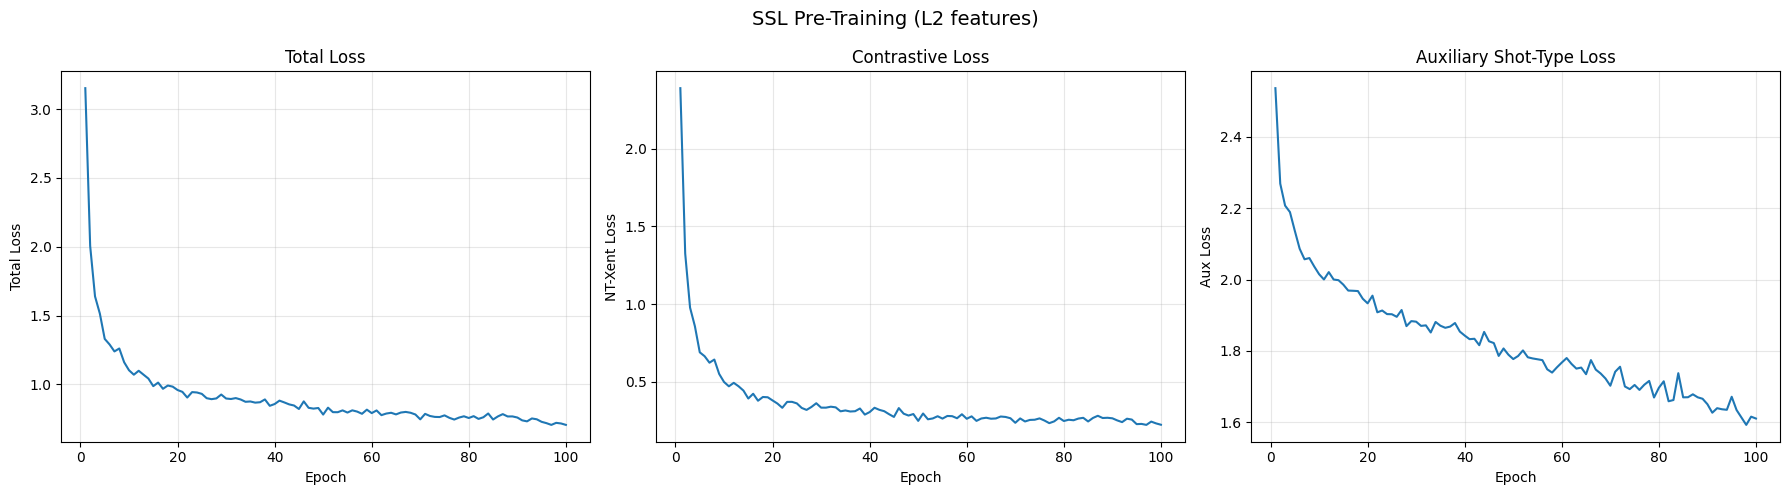

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history['epoch'], history['loss'])
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Total Loss')
axes[0].set_title('Total Loss')
axes[0].grid(True, alpha=0.3)

axes[1].plot(history['epoch'], history['contrastive_loss'])
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('NT-Xent Loss')
axes[1].set_title('Contrastive Loss')
axes[1].grid(True, alpha=0.3)

axes[2].plot(history['epoch'], history['aux_loss'])
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Aux Loss')
axes[2].set_title('Auxiliary Shot-Type Loss')
axes[2].grid(True, alpha=0.3)

plt.suptitle(f'SSL Pre-Training ({FEATURE_LAYER} features)', fontsize=14)
plt.tight_layout()
plt.savefig(RESULTS_DIR / f'ssl_training_{FEATURE_LAYER}.png', dpi=150)
plt.show()

## 7. Linear Probe Evaluation

Freeze the encoder and train a logistic regression on FineBadminton
strategy labels to assess representation quality.

In [ ]:
from src.data.dataset import FineBadmintonDataset
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, classification_report

# Load FineBadminton
fb_ds = FineBadmintonDataset(feature_layer=FEATURE_LAYER)
print(f"FineBadminton: {len(fb_ds)} samples")

# Extract embeddings with frozen encoder
encoder.eval()
all_embeddings = []
all_labels = []

with torch.no_grad():
    for i in range(len(fb_ds)):
        x, y = fb_ds[i]
        x = x.unsqueeze(0).to(device)
        emb = encoder(x).cpu().numpy()
        all_embeddings.append(emb[0])
        all_labels.append(y)

embeddings = np.array(all_embeddings)
labels = np.array(all_labels)
print(f"Embeddings: {embeddings.shape}")

# Cross-validated linear probe
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_f1s = []

for train_idx, test_idx in skf.split(embeddings, labels):
    clf = LogisticRegression(max_iter=1000, C=1.0)
    clf.fit(embeddings[train_idx], labels[train_idx])
    preds = clf.predict(embeddings[test_idx])
    f1 = f1_score(labels[test_idx], preds, average='macro')
    fold_f1s.append(f1)

print(f"\nLinear Probe Macro-F1: {np.mean(fold_f1s):.3f} ± {np.std(fold_f1s):.3f}")
print(f"Per-fold: {[f'{f:.3f}' for f in fold_f1s]}")